In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Project paths
PROJECT_DIR = Path("..")  # Assuming the notebook is inside /notebooks
DATA_DIR = PROJECT_DIR / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
FIGURES_DIR = PROJECT_DIR / "figures" / "01_dataset_generation"

SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Synthetic data directory:", SYNTHETIC_DIR.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

Synthetic data directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\data\synthetic
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\figures\01_dataset_generation


In [9]:
# Number of synthetic acquisitions
N = 1000

# Each row represents one simulated microCT acquisition / analyzed subvolume
sample_id = np.arange(1, N + 1)
time_index = np.arange(N)

# Experimental batches
n_batches = 20
batch_id = rng.integers(1, n_batches + 1, size=N)

# A/B protocols
# A: standard acquisition
# B: optimized acquisition
protocol = rng.choice(["A_standard", "B_optimized"], size=N, p=[0.5, 0.5])

df = pd.DataFrame({
    "sample_id": sample_id,
    "time_index": time_index,
    "batch_id": batch_id,
    "protocol": protocol
})

df.head()

,sample_id,time_index,batch_id,protocol
0,1,0,2,B_optimized
1,2,1,16,B_optimized
2,3,2,14,B_optimized
3,4,3,9,B_optimized
4,5,4,9,B_optimized


In [10]:
def generate_by_protocol(protocol_array, mean_a, std_a, mean_b, std_b, min_value=None, max_value=None):
    """
    Generate values depending on acquisition protocol.
    Protocol A and B are sampled from different normal distributions.
    """
    values = np.empty(len(protocol_array), dtype=float)

    mask_a = protocol_array == "A_standard"
    mask_b = protocol_array == "B_optimized"

    values[mask_a] = rng.normal(mean_a, std_a, mask_a.sum())
    values[mask_b] = rng.normal(mean_b, std_b, mask_b.sum())

    if min_value is not None:
        values = np.maximum(values, min_value)
    if max_value is not None:
        values = np.minimum(values, max_value)

    return values


# Acquisition parameters
df["voltage_kV"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=130, std_a=8,
    mean_b=135, std_b=6,
    min_value=100, max_value=160
)

df["current_uA"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=70, std_a=8,
    mean_b=80, std_b=8,
    min_value=40, max_value=120
)

df["exposure_ms"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=350, std_a=70,
    mean_b=650, std_b=90,
    min_value=100, max_value=1000
)

df["n_projections"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=900, std_a=120,
    mean_b=1600, std_b=180,
    min_value=400, max_value=2200
).round().astype(int)

df["voxel_size_um"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=80, std_a=10,
    mean_b=55, std_b=8,
    min_value=35, max_value=110
)

df["filter_thickness_mm"] = generate_by_protocol(
    df["protocol"].values,
    mean_a=0.5, std_a=0.15,
    mean_b=0.8, std_b=0.20,
    min_value=0.1, max_value=1.5
)

df.head()

,sample_id,time_index,batch_id,protocol,voltage_kV,current_uA,exposure_ms,n_projections,voxel_size_um,filter_thickness_mm
0,1,0,2,B_optimized,139.779264,79.740205,556.875111,1661,67.210426,1.017422
1,2,1,16,B_optimized,133.584995,88.224429,509.266539,1568,58.500142,0.841840
2,3,2,14,B_optimized,133.159816,79.573577,669.746240,1346,56.410341,1.085016
3,4,3,9,B_optimized,135.628140,79.754049,671.113602,1778,53.400963,0.566273
4,5,4,9,B_optimized,145.179520,75.327765,803.071348,1107,54.595544,0.742277


In [11]:
# True material / sample properties
# Porosity between roughly 2% and 18%
df["true_porosity"] = rng.beta(a=2.5, b=12, size=N) * 0.30
df["true_porosity"] = df["true_porosity"].clip(0.01, 0.22)

# Mean pore diameter in micrometers
df["true_mean_pore_diameter_um"] = rng.lognormal(
    mean=np.log(220),
    sigma=0.45,
    size=N
)
df["true_mean_pore_diameter_um"] = df["true_mean_pore_diameter_um"].clip(40, 900)

# Heterogeneity index: 0 = homogeneous, 1 = highly heterogeneous
df["true_heterogeneity"] = rng.beta(a=2, b=5, size=N)

# Effective sample thickness in mm
df["sample_thickness_mm"] = rng.normal(loc=8.0, scale=1.0, size=N).clip(5.0, 12.0)

df[[
    "true_porosity",
    "true_mean_pore_diameter_um",
    "true_heterogeneity",
    "sample_thickness_mm"
]].describe()

,true_porosity,true_mean_pore_diameter_um,true_heterogeneity,sample_thickness_mm
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.050259,238.793192,0.279914,8.073335
std,0.027832,112.413468,0.157416,1.019434
min,0.010000,57.693686,0.012455,5.000000
25%,0.028565,162.712731,0.158372,7.418145
50%,0.045832,218.469067,0.265318,8.065395
75%,0.066653,283.813216,0.374307,8.739702
max,0.149802,900.000000,0.878343,11.157756


In [12]:
# ------------------------------------------------------------
# Physics-informed signal model
# ------------------------------------------------------------

# Simplified attenuation coefficients.
# These values are not intended to represent a specific material exactly.
# They are chosen to generate realistic synthetic trends.
mu_matrix_base = 0.22  # effective attenuation coefficient of solid matrix
mu_pore = 0.02         # pores / air-like phase

# Higher voltage generally reduces effective attenuation contrast.
# We model this with a mild inverse dependence on voltage.
voltage_ref = 130
df["mu_matrix_effective"] = mu_matrix_base * (voltage_ref / df["voltage_kV"]) ** 0.7

# Beer-Lambert transmitted intensities
df["intensity_matrix"] = np.exp(
    -df["mu_matrix_effective"] * df["sample_thickness_mm"]
)

df["intensity_pore"] = np.exp(
    -mu_pore * df["sample_thickness_mm"]
)

# Attenuation contrast between matrix and pores
df["attenuation_contrast"] = np.abs(
    df["intensity_pore"] - df["intensity_matrix"]
)

# Photon / count-like signal proxy
# Signal increases with current, exposure, and number of projections.
df["photon_signal"] = (
    df["current_uA"]
    * df["exposure_ms"]
    * df["n_projections"]
)

# Normalize signal to avoid very large numbers
df["photon_signal_norm"] = df["photon_signal"] / df["photon_signal"].median()

# Relative counting noise: proportional to 1 / sqrt(signal)
base_noise = 0.08
df["relative_noise"] = base_noise / np.sqrt(df["photon_signal_norm"])

# Add a small random experimental component
df["relative_noise"] += rng.normal(0, 0.005, size=N)
df["relative_noise"] = df["relative_noise"].clip(0.005, None)

# Signal-to-noise ratio and contrast-to-noise ratio
df["snr"] = df["intensity_matrix"] / df["relative_noise"]
df["cnr"] = df["attenuation_contrast"] / df["relative_noise"]

df[[
    "mu_matrix_effective",
    "attenuation_contrast",
    "photon_signal_norm",
    "relative_noise",
    "snr",
    "cnr"
]].describe()

,mu_matrix_effective,attenuation_contrast,photon_signal_norm,relative_noise,snr,cnr
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.218417,0.674743,1.364135,0.082476,2.472297,9.315656
std,0.009320,0.026233,0.869180,0.029642,1.142649,3.310768
min,0.196009,0.568192,0.227559,0.029856,0.501759,3.798672
25%,0.211823,0.659890,0.550574,0.054915,1.534087,6.265081
50%,0.217357,0.677980,1.000000,0.078141,2.270347,8.662521
75%,0.223922,0.692737,2.151239,0.108543,3.223014,12.073840
max,0.254427,0.733580,4.062246,0.164464,7.210905,22.998669


In [16]:
# ------------------------------------------------------------
# Spatial detectability and temporal drift
# ------------------------------------------------------------

# Detectability ratio
# Larger values mean pores are better resolved by the voxel size.
df["pore_detectability"] = (
    df["true_mean_pore_diameter_um"] / df["voxel_size_um"]
)

# Bounded detectability score between 0 and 1.
# This smooth function represents the idea that segmentation improves
# when pore size becomes several times larger than the voxel size.
df["detectability_score"] = 1 / (
    1 + np.exp(-(df["pore_detectability"] - 3.0))
)

# Smooth detector drift across acquisition time.
# Positive values increase noise slowly with time.
drift_strength = 0.00025
df["detector_drift"] = 1 + drift_strength * df["time_index"]

# Apply drift to noise-related quantities
df["relative_noise_drifted"] = df["relative_noise"] * df["detector_drift"]

# Recompute SNR and CNR with drift
df["snr_drifted"] = df["intensity_matrix"] / df["relative_noise_drifted"]
df["cnr_drifted"] = df["attenuation_contrast"] / df["relative_noise_drifted"]

df[[
    "voxel_size_um",
    "true_mean_pore_diameter_um",
    "pore_detectability",
    "detectability_score",
    "relative_noise",
    "detector_drift",
    "relative_noise_drifted",
    "snr_drifted",
    "cnr_drifted"
]].describe()

,voxel_size_um,true_mean_pore_diameter_um,pore_detectability,detectability_score,relative_noise,detector_drift,relative_noise_drifted,snr_drifted,cnr_drifted
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,68.258157,238.793192,3.709467,0.576209,0.082476,1.124875,0.092840,2.208522,8.318355
std,15.801982,112.413468,2.019886,0.271894,0.029642,0.072205,0.034213,1.036254,3.009381
min,35.000000,57.693686,0.990539,0.118213,0.029856,1.000000,0.033087,0.413907,3.134218
25%,54.753607,162.712731,2.319388,0.336125,0.054915,1.062437,0.062081,1.364981,5.559793
50%,67.397025,218.469067,3.269874,0.567062,0.078141,1.124875,0.084929,2.016585,7.960181
75%,81.537086,283.813216,4.602076,0.832308,0.108543,1.187312,0.122532,2.900860,10.798559
max,110.000000,900.000000,17.142226,0.999999,0.164464,1.249750,0.196086,6.301351,20.752239


In [17]:
# ------------------------------------------------------------
# Segmentation error model
# ------------------------------------------------------------

# The objective of this model is to generate a segmentation error that is
# physically motivated and statistically learnable.
#
# Main assumptions:
# - Lower CNR increases segmentation error.
# - Poor spatial detectability increases segmentation error.
# - Higher heterogeneity increases segmentation difficulty.
# - Higher relative noise increases the probability of false positives/negatives.
# - Higher true porosity increases structural complexity.

# Error components
cnr_error_component = 0.055 / (df["cnr_drifted"] + 0.8)

resolution_error_component = 0.045 * (1 - df["detectability_score"])

heterogeneity_error_component = 0.030 * df["true_heterogeneity"]

noise_error_component = 0.35 * df["relative_noise_drifted"]

porosity_complexity_component = 0.035 * df["true_porosity"]

# Smaller random component, so that the physical relationships remain visible
random_error_component = rng.normal(0, 0.003, size=N)

df["segmentation_abs_error"] = (
    cnr_error_component
    + resolution_error_component
    + heterogeneity_error_component
    + noise_error_component
    + porosity_complexity_component
    + np.abs(random_error_component)
)

# Segmentation bias:
# Poor detectability tends to underestimate porosity.
# High noise can introduce false positives.
# Heterogeneous samples add a small systematic variability.
undersegmentation_bias = -0.040 * (1 - df["detectability_score"])

false_positive_bias = 0.100 * df["relative_noise_drifted"]

heterogeneity_bias = 0.010 * (
    df["true_heterogeneity"] - df["true_heterogeneity"].mean()
)

df["segmentation_bias"] = (
    undersegmentation_bias
    + false_positive_bias
    + heterogeneity_bias
    + rng.normal(0, 0.0025, size=N)
)

# Estimated porosity
# Measurement noise is proportional to expected segmentation error,
# but not so large that it hides the physics-informed relationships.
measurement_noise = rng.normal(
    0,
    df["segmentation_abs_error"] / 5,
    size=N
)

df["estimated_porosity"] = (
    df["true_porosity"]
    + df["segmentation_bias"]
    + measurement_noise
)

df["estimated_porosity"] = df["estimated_porosity"].clip(0, 0.35)

# Signed and absolute porosity error
df["porosity_error"] = df["estimated_porosity"] - df["true_porosity"]
df["abs_porosity_error"] = np.abs(df["porosity_error"])

# Estimated mean pore diameter
# Poor detectability tends to underestimate pore size.
df["estimated_mean_pore_diameter_um"] = (
    df["true_mean_pore_diameter_um"]
    * (0.88 + 0.12 * df["detectability_score"])
    + rng.normal(0, 20, size=N)
)

df["estimated_mean_pore_diameter_um"] = (
    df["estimated_mean_pore_diameter_um"].clip(10, None)
)

df[[
    "true_porosity",
    "estimated_porosity",
    "porosity_error",
    "abs_porosity_error",
    "segmentation_abs_error",
    "true_mean_pore_diameter_um",
    "estimated_mean_pore_diameter_um"
]].describe()

,true_porosity,estimated_porosity,porosity_error,abs_porosity_error,segmentation_abs_error,true_mean_pore_diameter_um,estimated_mean_pore_diameter_um
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,0.050259,0.043647,-0.006612,1.402302e-02,0.070952,238.793192,229.534847
std,0.027832,0.031070,0.016491,1.090285e-02,0.022127,112.413468,116.294760
min,0.010000,0.000000,-0.062955,7.663868e-07,0.027438,57.693686,41.954254
25%,0.028565,0.019794,-0.016655,5.846905e-03,0.051989,162.712731,151.327369
50%,0.045832,0.039995,-0.006497,1.139868e-02,0.069681,218.469067,204.761021
75%,0.066653,0.062518,0.005169,1.923134e-02,0.089049,283.813216,277.039309
max,0.149802,0.151089,0.040987,6.295477e-02,0.129141,900.000000,879.044515


In [18]:
# ------------------------------------------------------------
# Experimental outliers
# ------------------------------------------------------------

# These represent failed acquisitions, motion artifacts, reconstruction issues,
# or unstable segmentation results.
outlier_fraction = 0.03
n_outliers = int(N * outlier_fraction)

outlier_indices = rng.choice(df.index, size=n_outliers, replace=False)

df["is_outlier"] = False
df.loc[outlier_indices, "is_outlier"] = True

# Outliers have worse noise and higher segmentation uncertainty,
# but the perturbation is kept moderate so that the regression problem
# remains learnable.
df.loc[outlier_indices, "relative_noise_drifted"] *= rng.uniform(
    1.6,
    2.4,
    size=n_outliers
)

# Recompute SNR and CNR after increasing noise in outlier cases
df.loc[outlier_indices, "snr_drifted"] = (
    df.loc[outlier_indices, "intensity_matrix"]
    / df.loc[outlier_indices, "relative_noise_drifted"]
)

df.loc[outlier_indices, "cnr_drifted"] = (
    df.loc[outlier_indices, "attenuation_contrast"]
    / df.loc[outlier_indices, "relative_noise_drifted"]
)

# Outliers perturb the estimated porosity
df.loc[outlier_indices, "estimated_porosity"] += rng.normal(
    0,
    0.025,
    size=n_outliers
)

df["estimated_porosity"] = df["estimated_porosity"].clip(0, 0.35)

# Recompute observed errors after outlier perturbation
df["porosity_error"] = df["estimated_porosity"] - df["true_porosity"]
df["abs_porosity_error"] = np.abs(df["porosity_error"])

# Also increase expected segmentation error in outlier cases
df.loc[outlier_indices, "segmentation_abs_error"] *= rng.uniform(
    1.3,
    1.8,
    size=n_outliers
)

print("Outlier counts:")
print(df["is_outlier"].value_counts())

df[[
    "relative_noise_drifted",
    "snr_drifted",
    "cnr_drifted",
    "segmentation_abs_error",
    "abs_porosity_error"
]].describe()

Outlier counts:
is_outlier
False    970
True      30
Name: count, dtype: int64


,relative_noise_drifted,snr_drifted,cnr_drifted,segmentation_abs_error,abs_porosity_error
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,0.095527,2.175168,8.188166,0.071984,1.433765e-02
std,0.038823,1.043825,3.047683,0.023123,1.130710e-02
min,0.033087,0.413907,1.984404,0.027438,7.663868e-07
25%,0.062592,1.339998,5.497135,0.052584,6.025201e-03
50%,0.091924,1.965652,7.399942,0.070289,1.159697e-02
75%,0.123622,2.869105,10.745729,0.090025,1.966800e-02
max,0.344169,6.301351,20.752239,0.174409,6.401317e-02


In [20]:
# ------------------------------------------------------------
# Synthetic quality score
# ------------------------------------------------------------

# This score is not a physical measurement.
# It is a synthetic summary metric designed to combine:
# - high SNR
# - high CNR
# - good pore detectability
# - low expected segmentation error
# - low observed porosity error

def min_max_scale(series):
    """Scale a pandas Series to the [0, 1] range."""
    return (series - series.min()) / (series.max() - series.min())


snr_norm = min_max_scale(df["snr_drifted"])
cnr_norm = min_max_scale(df["cnr_drifted"])
detectability_norm = df["detectability_score"]

# Errors are inverted because lower error means higher quality
segmentation_error_norm = min_max_scale(df["segmentation_abs_error"])
observed_error_norm = min_max_scale(df["abs_porosity_error"])

df["quality_score"] = (
    100
    * (
        0.25 * snr_norm
        + 0.25 * cnr_norm
        + 0.20 * detectability_norm
        + 0.20 * (1 - segmentation_error_norm)
        + 0.10 * (1 - observed_error_norm)
    )
)

# Penalize outliers
df.loc[df["is_outlier"], "quality_score"] *= 0.65

df["quality_score"] = df["quality_score"].clip(0, 100)

numeric_summary_columns = [
    "snr_drifted",
    "cnr_drifted",
    "detectability_score",
    "segmentation_abs_error",
    "abs_porosity_error",
    "quality_score"
]

display(df[numeric_summary_columns].describe())

print("Protocol counts:")
print(df["protocol"].value_counts())

print("\nOutlier counts:")
print(df["is_outlier"].value_counts())

,snr_drifted,cnr_drifted,detectability_score,segmentation_abs_error,abs_porosity_error,quality_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,2.175168,8.188166,0.576209,0.071984,1.433765e-02,48.613287
std,1.043825,3.047683,0.271894,0.023123,1.130710e-02,15.175519
min,0.413907,1.984404,0.118213,0.027438,7.663868e-07,8.227662
25%,1.339998,5.497135,0.336125,0.052584,6.025201e-03,35.916795
50%,1.965652,7.399942,0.567062,0.070289,1.159697e-02,47.750985
75%,2.869105,10.745729,0.832308,0.090025,1.966800e-02,61.217733
max,6.301351,20.752239,0.999999,0.174409,6.401317e-02,88.883976


Protocol counts:
protocol
A_standard     509
B_optimized    491
Name: count, dtype: int64

Outlier counts:
is_outlier
False    970
True      30
Name: count, dtype: int64


In [21]:
# ------------------------------------------------------------
# Final column order
# ------------------------------------------------------------

columns_order = [
    # Identification
    "sample_id",
    "time_index",
    "batch_id",
    "protocol",
    "is_outlier",

    # Acquisition parameters
    "voltage_kV",
    "current_uA",
    "exposure_ms",
    "n_projections",
    "voxel_size_um",
    "filter_thickness_mm",

    # True sample properties
    "true_porosity",
    "true_mean_pore_diameter_um",
    "true_heterogeneity",
    "sample_thickness_mm",

    # Physics-informed variables
    "mu_matrix_effective",
    "intensity_matrix",
    "intensity_pore",
    "attenuation_contrast",
    "photon_signal",
    "photon_signal_norm",
    "relative_noise",
    "detector_drift",
    "relative_noise_drifted",
    "snr",
    "cnr",
    "snr_drifted",
    "cnr_drifted",

    # Resolution / detectability
    "pore_detectability",
    "detectability_score",

    # Segmentation outputs
    "segmentation_bias",
    "segmentation_abs_error",
    "estimated_porosity",
    "porosity_error",
    "abs_porosity_error",
    "estimated_mean_pore_diameter_um",

    # Final synthetic metric
    "quality_score"
]

# Check if any expected column is missing before reordering
missing_columns = [col for col in columns_order if col not in df.columns]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    df = df[columns_order]
    print("Column order applied successfully.")
    print("Dataset shape:", df.shape)

df.head()

Column order applied successfully.
Dataset shape: (1000, 37)


,sample_id,time_index,batch_id,protocol,is_outlier,voltage_kV,current_uA,exposure_ms,n_projections,voxel_size_um,...,cnr_drifted,pore_detectability,detectability_score,segmentation_bias,segmentation_abs_error,estimated_porosity,porosity_error,abs_porosity_error,estimated_mean_pore_diameter_um,quality_score
0,1,0,2,B_optimized,False,139.779264,79.740205,556.875111,1661,67.210426,...,11.970542,4.498315,0.817323,-0.000816,0.040911,0.028641,-0.015902,0.015902,287.169132,68.535130
1,2,1,16,B_optimized,False,133.584995,88.224429,509.266539,1568,58.500142,...,11.447199,2.712877,0.428708,-0.018846,0.058534,0.024571,-0.030900,0.030900,155.735321,60.565095
2,3,2,14,B_optimized,False,133.159816,79.573577,669.746240,1346,56.410341,...,13.206688,1.589025,0.196080,-0.026190,0.072801,0.027155,-0.021571,0.021571,77.601924,53.103840
3,4,3,9,B_optimized,False,135.628140,79.754049,671.113602,1778,53.400963,...,13.997532,3.189257,0.547174,-0.019235,0.052760,0.007369,-0.015688,0.015688,143.422889,66.903072
4,5,4,9,B_optimized,False,145.179520,75.327765,803.071348,1107,54.595544,...,9.636927,10.265431,0.999301,0.005620,0.038226,0.050214,0.003226,0.003226,546.998549,72.247540


In [22]:
# ------------------------------------------------------------
# Basic sanity checks
# ------------------------------------------------------------

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nProtocol counts:")
print(df["protocol"].value_counts())

print("\nOutlier counts:")
print(df["is_outlier"].value_counts())

print("\nTarget summaries:")
display(
    df[[
        "segmentation_abs_error",
        "abs_porosity_error",
        "quality_score",
        "snr_drifted",
        "cnr_drifted",
        "detectability_score"
    ]].describe()
)

Dataset shape: (1000, 37)

Missing values:
sample_id        0
time_index       0
batch_id         0
protocol         0
is_outlier       0
voltage_kV       0
current_uA       0
exposure_ms      0
n_projections    0
voxel_size_um    0
dtype: int64

Protocol counts:
protocol
A_standard     509
B_optimized    491
Name: count, dtype: int64

Outlier counts:
is_outlier
False    970
True      30
Name: count, dtype: int64

Target summaries:


,segmentation_abs_error,abs_porosity_error,quality_score,snr_drifted,cnr_drifted,detectability_score
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.071984,1.433765e-02,48.613287,2.175168,8.188166,0.576209
std,0.023123,1.130710e-02,15.175519,1.043825,3.047683,0.271894
min,0.027438,7.663868e-07,8.227662,0.413907,1.984404,0.118213
25%,0.052584,6.025201e-03,35.916795,1.339998,5.497135,0.336125
50%,0.070289,1.159697e-02,47.750985,1.965652,7.399942,0.567062
75%,0.090025,1.966800e-02,61.217733,2.869105,10.745729,0.832308
max,0.174409,6.401317e-02,88.883976,6.301351,20.752239,0.999999


In [23]:
# ------------------------------------------------------------
# Quick protocol comparison
# ------------------------------------------------------------

protocol_summary = (
    df
    .groupby("protocol")
    .agg(
        n=("sample_id", "count"),
        outlier_rate=("is_outlier", "mean"),
        mean_exposure_ms=("exposure_ms", "mean"),
        mean_n_projections=("n_projections", "mean"),
        mean_voxel_size_um=("voxel_size_um", "mean"),
        mean_snr=("snr_drifted", "mean"),
        mean_cnr=("cnr_drifted", "mean"),
        mean_detectability=("detectability_score", "mean"),
        mean_segmentation_abs_error=("segmentation_abs_error", "mean"),
        mean_abs_porosity_error=("abs_porosity_error", "mean"),
        mean_quality_score=("quality_score", "mean"),
    )
    .round(4)
)

protocol_summary

,n,outlier_rate,mean_exposure_ms,mean_n_projections,mean_voxel_size_um,mean_snr,mean_cnr,mean_detectability,mean_segmentation_abs_error,mean_abs_porosity_error,mean_quality_score
protocol,,,,,,,,,,,
A_standard,509,0.0255,350.0093,895.0000,80.7445,1.4153,5.6322,0.4743,0.0886,0.0158,37.5863
B_optimized,491,0.0346,649.6284,1604.2281,55.3140,2.9629,10.8378,0.6819,0.0548,0.0128,60.0445


Saved: ..\figures\01_dataset_generation\true_porosity_distribution.png


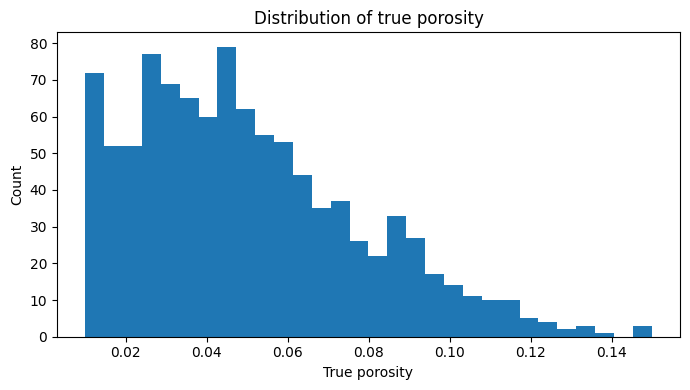

Saved: ..\figures\01_dataset_generation\relative_noise_vs_exposure.png


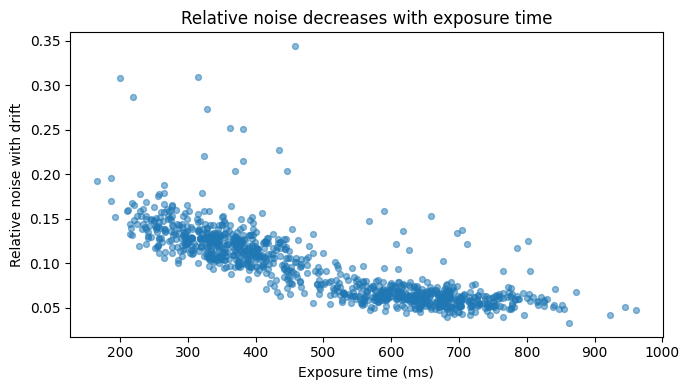

Saved: ..\figures\01_dataset_generation\segmentation_error_vs_cnr.png


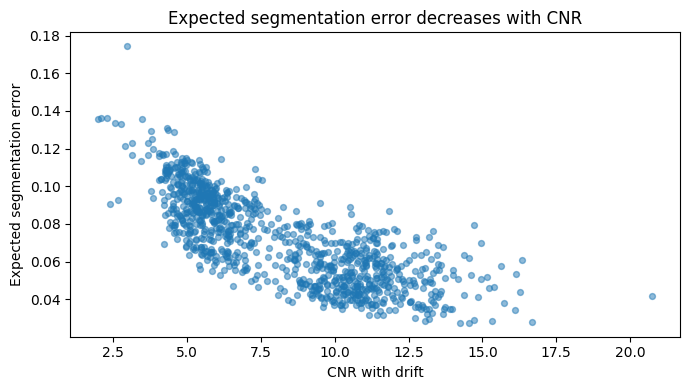

Saved: ..\figures\01_dataset_generation\detectability_vs_segmentation_error.png


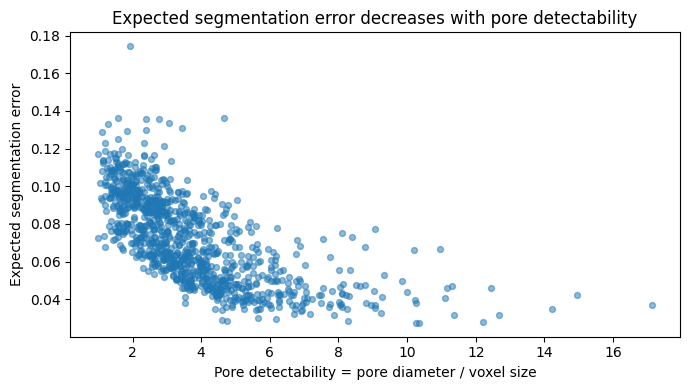

Saved: ..\figures\01_dataset_generation\expected_vs_observed_error.png


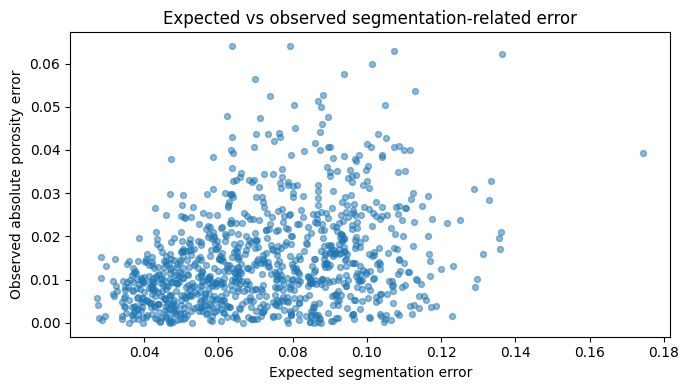

C:\Users\Peter\AppData\Local\Temp\ipykernel_11584\2980116601.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_a, data_b], labels=["A_standard", "B_optimized"])


Saved: ..\figures\01_dataset_generation\quality_score_by_protocol.png


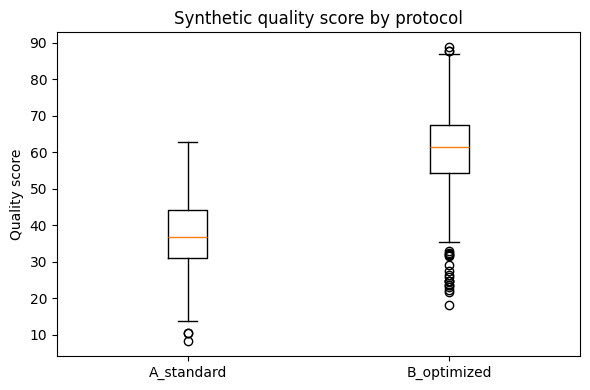

Saved: ..\figures\01_dataset_generation\temporal_snr_drift.png


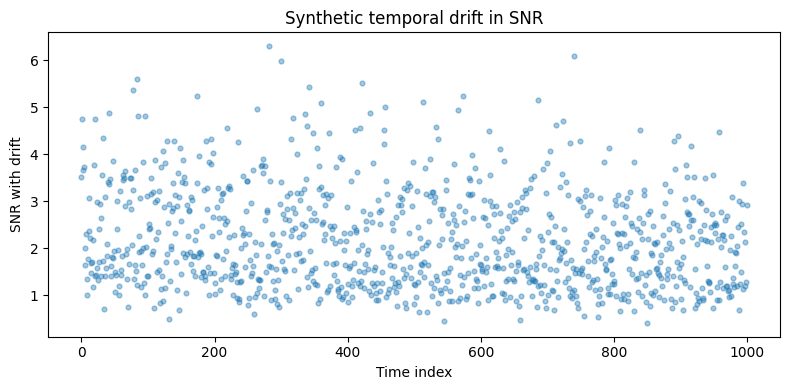

In [24]:
# ------------------------------------------------------------
# Control figures
# ------------------------------------------------------------

def save_current_figure(filename):
    output_path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()


# 1. True porosity distribution
plt.figure(figsize=(7, 4))
plt.hist(df["true_porosity"], bins=30)
plt.xlabel("True porosity")
plt.ylabel("Count")
plt.title("Distribution of true porosity")
save_current_figure("true_porosity_distribution.png")


# 2. Relative noise vs exposure time
plt.figure(figsize=(7, 4))
plt.scatter(
    df["exposure_ms"],
    df["relative_noise_drifted"],
    alpha=0.5,
    s=18
)
plt.xlabel("Exposure time (ms)")
plt.ylabel("Relative noise with drift")
plt.title("Relative noise decreases with exposure time")
save_current_figure("relative_noise_vs_exposure.png")


# 3. Expected segmentation error vs CNR
plt.figure(figsize=(7, 4))
plt.scatter(
    df["cnr_drifted"],
    df["segmentation_abs_error"],
    alpha=0.5,
    s=18
)
plt.xlabel("CNR with drift")
plt.ylabel("Expected segmentation error")
plt.title("Expected segmentation error decreases with CNR")
save_current_figure("segmentation_error_vs_cnr.png")


# 4. Detectability vs expected segmentation error
plt.figure(figsize=(7, 4))
plt.scatter(
    df["pore_detectability"],
    df["segmentation_abs_error"],
    alpha=0.5,
    s=18
)
plt.xlabel("Pore detectability = pore diameter / voxel size")
plt.ylabel("Expected segmentation error")
plt.title("Expected segmentation error decreases with pore detectability")
save_current_figure("detectability_vs_segmentation_error.png")


# 5. Expected segmentation error vs observed absolute porosity error
plt.figure(figsize=(7, 4))
plt.scatter(
    df["segmentation_abs_error"],
    df["abs_porosity_error"],
    alpha=0.5,
    s=18
)
plt.xlabel("Expected segmentation error")
plt.ylabel("Observed absolute porosity error")
plt.title("Expected vs observed segmentation-related error")
save_current_figure("expected_vs_observed_error.png")


# 6. Quality score by protocol
plt.figure(figsize=(6, 4))
data_a = df.loc[df["protocol"] == "A_standard", "quality_score"]
data_b = df.loc[df["protocol"] == "B_optimized", "quality_score"]

plt.boxplot([data_a, data_b], labels=["A_standard", "B_optimized"])
plt.ylabel("Quality score")
plt.title("Synthetic quality score by protocol")
save_current_figure("quality_score_by_protocol.png")


# 7. Temporal SNR drift
plt.figure(figsize=(8, 4))
plt.scatter(
    df["time_index"],
    df["snr_drifted"],
    alpha=0.4,
    s=12
)
plt.xlabel("Time index")
plt.ylabel("SNR with drift")
plt.title("Synthetic temporal drift in SNR")
save_current_figure("temporal_snr_drift.png")

In [25]:
# ------------------------------------------------------------
# Final sanity check: expected relationships
# ------------------------------------------------------------

check_columns = [
    "abs_porosity_error",
    "segmentation_abs_error",
    "relative_noise_drifted",
    "cnr_drifted",
    "snr_drifted",
    "detectability_score",
    "pore_detectability",
    "voxel_size_um",
    "true_heterogeneity",
    "quality_score"
]

print("Correlation with observed absolute porosity error:")
display(
    df[check_columns]
    .corr(numeric_only=True)["abs_porosity_error"]
    .sort_values(ascending=False)
)

print("\nCorrelation with expected segmentation error:")
display(
    df[check_columns]
    .corr(numeric_only=True)["segmentation_abs_error"]
    .sort_values(ascending=False)
)

Correlation with observed absolute porosity error:


abs_porosity_error        1.000000
segmentation_abs_error    0.318826
relative_noise_drifted    0.181941
voxel_size_um             0.167935
true_heterogeneity        0.028704
cnr_drifted              -0.165895
snr_drifted              -0.169864
pore_detectability       -0.296553
detectability_score      -0.353260
quality_score            -0.421694
Name: abs_porosity_error, dtype: float64


Correlation with expected segmentation error:


segmentation_abs_error    1.000000
relative_noise_drifted    0.807209
voxel_size_um             0.684792
abs_porosity_error        0.318826
true_heterogeneity        0.165420
pore_detectability       -0.670973
snr_drifted              -0.677556
detectability_score      -0.751169
cnr_drifted              -0.783506
quality_score            -0.945512
Name: segmentation_abs_error, dtype: float64

In [26]:
# ------------------------------------------------------------
# Save synthetic dataset
# ------------------------------------------------------------

output_csv = SYNTHETIC_DIR / "microct_statistics_dataset.csv"

df.to_csv(output_csv, index=False)

print(f"Dataset saved to: {output_csv.resolve()}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset saved to: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\data\synthetic\microct_statistics_dataset.csv
Rows: 1000
Columns: 37


In [27]:
# ------------------------------------------------------------
# Notebook completion message
# ------------------------------------------------------------

print("Synthetic dataset generation completed.")
print()
print("This dataset includes:")
print("- Acquisition parameters")
print("- Physics-informed signal and noise variables")
print("- Spatial detectability metrics")
print("- Temporal detector drift")
print("- Experimental outliers")
print("- Expected segmentation error")
print("- Observed porosity error")
print("- A/B acquisition protocols")
print("- Synthetic quality score")
print()
print("Main output:")
print(f"- {output_csv}")

Synthetic dataset generation completed.

This dataset includes:
- Acquisition parameters
- Physics-informed signal and noise variables
- Spatial detectability metrics
- Temporal detector drift
- Experimental outliers
- Expected segmentation error
- Observed porosity error
- A/B acquisition protocols
- Synthetic quality score

Main output:
- ..\data\synthetic\microct_statistics_dataset.csv
